In [1]:
pip install yfinance matplotlib numpy scipy pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime

In [41]:
TICKER = "AAPL"
RISK_FREE_RATE = 0.04  # Approx 4%

In [42]:
# Fetching the Stock Data
stock = yf.Ticker(TICKER)
spot_price = stock.history(period="1d")['Close'].iloc[-1]
div_yield = stock.info.get('dividendYield', 0.005) # Default to 0.5% if missing


print(f"--- LIVE MARKET INPUTS FOR {TICKER} ---")
print(f"Spot Price (S): ${spot_price:.2f}")
print(f"Risk-Free Rate (r): {RISK_FREE_RATE:.1%}")
print(f"Dividend Yield (q): {div_yield:.1%}")

--- LIVE MARKET INPUTS FOR AAPL ---
Spot Price (S): $255.78
Risk-Free Rate (r): 4.0%
Dividend Yield (q): 41.0%


In [43]:
# Building the Implied Volatility Surface

options_data = []
expirations = stock.options[:4] # Grabing the next 4 expiration dates

print(f"\nScanning Option Chains: {expirations}...")

for date_str in expirations:
    expiry_date = datetime.strptime(date_str, "%Y-%m-%d")
    today = datetime.now()
    # Calculate Time to Maturity (T) in years
    T = (expiry_date - today).days / 365.0 
    
    if T < 0.01: continue # Skip if expiring immediately (Wedo not need too noisy data)

    # Getting the chain
    chain = stock.option_chain(date_str)
    calls = chain.calls
    
    # DATA CLEANING (Real-Life Adjustment)
    # 1. Calculate Mid Price
    calls['midPrice'] = (calls['bid'] + calls['ask']) / 2
    
    # 2. Filter: Remove illiquid options (Volume=0 or weird spreads)
    calls = calls[ (calls['volume'] > 0) & (calls['midPrice'] > 0.05) ]
    
    # 3. Calculate Forward Price for this expiration
    # Formula: F = S * e^((r-q)T)
    F = spot_price * np.exp((RISK_FREE_RATE - div_yield) * T)
    
    for index, row in calls.iterrows():
        # We use the IV provided by Yahoo, which is "Back-Calculated" 
        # using a similar solver to what we discussed.
        iv = row['impliedVolatility']
        
        # Filter extreme IVs (garbage data)
        #AAPL rarely has volatility below 10%. If the data says "1% volatility," it's likely a data error or a calculation glitch.
        # Unless AAPL is going bankrupt tomorrow, volatility shouldn't be 150%. If the data says "500% volatility," it’s usually because the option is deep "in the money" or deep "out of the money" and the math is breaking down.
        if 0.1 < iv < 1.5: 
            options_data.append({
                'Strike': row['strike'],
                'Time': T,
                'IV': iv,
                'ForwardPrice': F,
                'MarketPrice': row['midPrice']
            })

df = pd.DataFrame(options_data)
print(f"Surface Built! Collected {len(df)} data points.")
df.head()


Scanning Option Chains: ('2026-02-18', '2026-02-20', '2026-02-23', '2026-02-25')...
Surface Built! Collected 70 data points.


,Strike,Time,IV,ForwardPrice,MarketPrice
0,175.0,0.010959,1.447268,254.744963,81.075
1,180.0,0.010959,1.062505,254.744963,75.825
2,185.0,0.010959,1.362308,254.744963,71.250
3,190.0,0.010959,1.265629,254.744963,66.250
4,195.0,0.010959,1.123051,254.744963,61.150


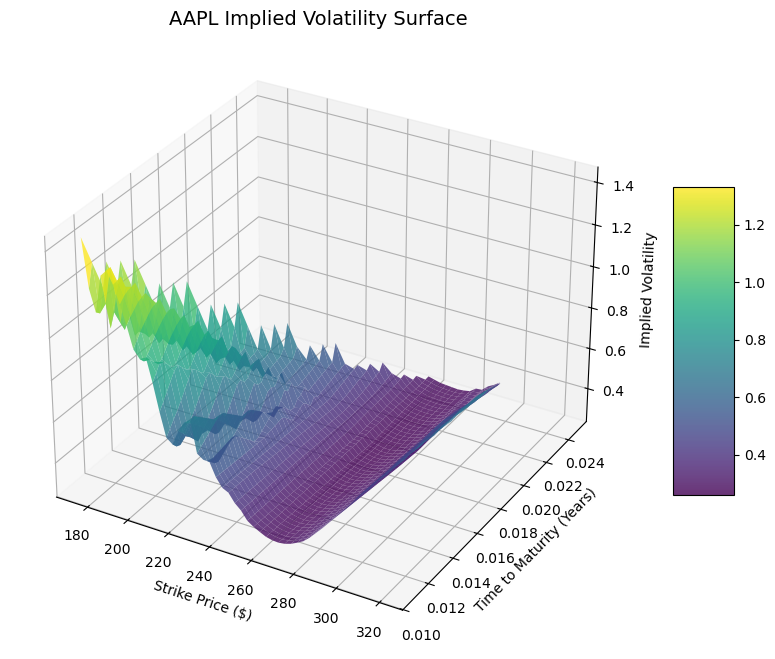

In [44]:
#Visualizing the Volatility Surface
# Prepare 3D Data
x = df['Strike']
y = df['Time']
z = df['IV']

# Create a grid for smooth plotting (Interpolation)
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x, y), z, (xi, yi), method='linear')

# Plotting the graph
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_title(f'{TICKER} Implied Volatility Surface', fontsize=14)
ax.set_xlabel('Strike Price ($)')
ax.set_ylabel('Time to Maturity (Years)')
ax.set_zlabel('Implied Volatility')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [45]:
# Calculatin the Greeks now
def calculate_greeks(S, K, T, r, q, sigma):
    """
    Calculates Analytical Greeks using Black-Scholes formulas.
    """
    # 1. Calculate d1 (The "Probability" location)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    
    # 2. Calculate d2
    d2 = d1 - sigma * np.sqrt(T)
    
    # 3. Calculate Greeks
    # Delta: Directional Risk
    delta = np.exp(-q * T) * norm.cdf(d1)
    
    # Vega: Volatility Risk (Sensitivity to 1% change in IV)
    vega = S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1) / 100 
    
    return delta, vega, d1


In [46]:
# Test on a specific option from our data (e.g., slightly Out of The Money)
test_option = df.iloc[len(df)//2] # Pick a random middle option
K_test = test_option['Strike']
T_test = test_option['Time']
IV_test = test_option['IV']

delta_val, vega_val, d1_val = calculate_greeks(spot_price, K_test, T_test, RISK_FREE_RATE, div_yield, IV_test)

print(f"--- ANALYTICAL GREEKS FOR STRIKE ${K_test} ---")
print(f"Inputs: Spot=${spot_price:.2f}, Time={T_test:.2f} yrs, IV={IV_test:.1%}")
print(f"d1 Value: {d1_val:.4f}")
print(f"Delta: {delta_val:.4f} (Equivalent to {int(delta_val*100)} shares)")
print(f"Vega:  ${vega_val:.4f} (Change in option price if IV goes +1%)")

--- ANALYTICAL GREEKS FOR STRIKE $245.0 ---
Inputs: Spot=$255.78, Time=0.02 yrs, IV=38.1%
d1 Value: 0.7078
Delta: 0.7545 (Equivalent to 75 shares)
Vega:  $0.1091 (Change in option price if IV goes +1%)


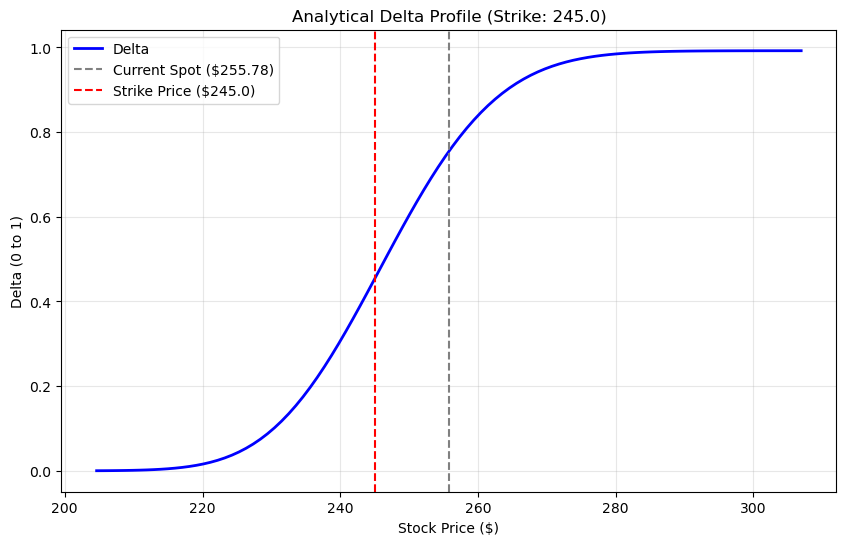

In [47]:
# Simulate stock prices from -20% to +20%
simulated_spots = np.linspace(spot_price * 0.8, spot_price * 1.2, 100)

# Calculate Delta for each simulated price (holding Time and Volatility constant)
deltas = [calculate_greeks(s, K_test, T_test, RISK_FREE_RATE, div_yield, IV_test)[0] for s in simulated_spots]

plt.figure(figsize=(10, 6))
plt.plot(simulated_spots, deltas, color='blue', linewidth=2, label='Delta')
plt.axvline(spot_price, color='gray', linestyle='--', label=f'Current Spot (${spot_price:.2f})')
plt.axvline(K_test, color='red', linestyle='--', label=f'Strike Price (${K_test})')

plt.title(f"Analytical Delta Profile (Strike: {K_test})")
plt.xlabel("Stock Price ($)")
plt.ylabel("Delta (0 to 1)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

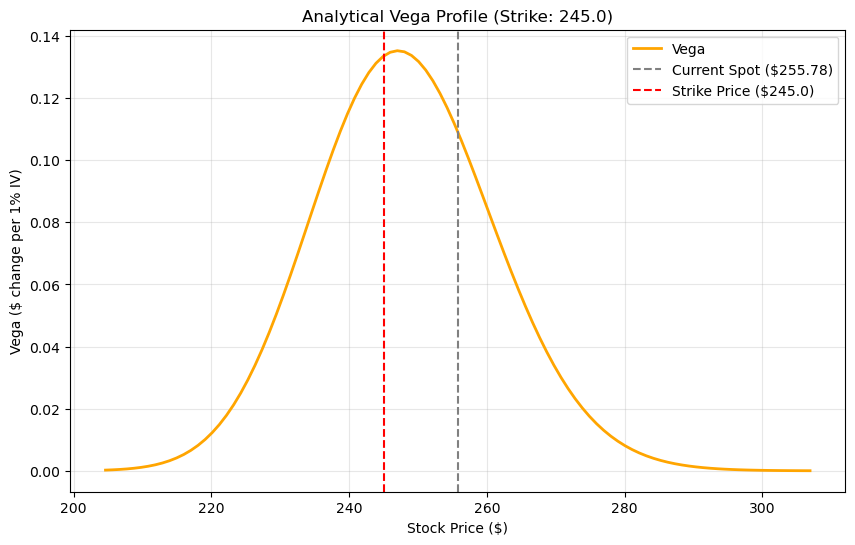

Current Vega: $0.1091
Interpretation: If Implied Volatility jumps from 38.1% to 39.1%,
this option's price will INCREASE by approximately $0.11.


In [48]:
# 1. Use the same simulated prices from Step 5
# simulated_spots = np.linspace(spot_price * 0.8, spot_price * 1.2, 100)

# 2. Calculate Vega for each simulated price
# We extract the second return value [1] from our function which corresponds to Vega
vegas = [calculate_greeks(s, K_test, T_test, RISK_FREE_RATE, div_yield, IV_test)[1] for s in simulated_spots]

# 3. Plotting the Graph
plt.figure(figsize=(10, 6))
plt.plot(simulated_spots, vegas, color='orange', linewidth=2, label='Vega')

# Add markers for current Spot and Strike
plt.axvline(spot_price, color='gray', linestyle='--', label=f'Current Spot (${spot_price:.2f})')
plt.axvline(K_test, color='red', linestyle='--', label=f'Strike Price (${K_test})')

# Formatting
plt.title(f"Analytical Vega Profile (Strike: {K_test})")
plt.xlabel("Stock Price ($)")
plt.ylabel("Vega ($ change per 1% IV)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Print interpretation
current_vega = calculate_greeks(spot_price, K_test, T_test, RISK_FREE_RATE, div_yield, IV_test)[1]
print(f"Current Vega: ${current_vega:.4f}")
print(f"Interpretation: If Implied Volatility jumps from {IV_test:.1%} to {IV_test+0.01:.1%},")
print(f"this option's price will INCREASE by approximately ${current_vega:.2f}.")

### The Peak: You will see the orange line peaks right around the Strike Price (260 $). This means "At-The-Money" options are the most sensitive to volatility changes.

### The Wings: As the stock moves far away (deep In-The-Money or deep Out-Of-The-Money), Vega drops to near zero. If an option is already guaranteed to win or lose, changes in "market fear" don't matter as much.

## The above was more of simulated data, lets us try to check out the real world messier data

In [49]:
# We look back at the "Real World" since the start of the year
history = stock.history(start="2026-01-01")
# Let's pretend we hold a Call Option that expires next month
target_strike = 260
target_expiry = "2026-03-20"
expiry_dt = datetime.strptime(target_expiry, "%Y-%m-%d")
print(f"Tracking Option: Strike ${target_strike}, Expiring {target_expiry}")

Tracking Option: Strike $260, Expiring 2026-03-20


In [50]:
# Calculate Greeks for every single day in history
historical_greeks = []

for date, row in history.iterrows():
    spot = row['Close']
    
    # Calculate Time to Maturity (T) for that specific date
    # T gets smaller every day (Time Decay!)
    T_real = (expiry_dt - date.to_pydatetime().replace(tzinfo=None)).days / 365.0
    
    if T_real < 0: continue # Skip if expired
    
    # We use a fixed IV here (e.g., 28% - Google Search) because we can't get historical IVs for free.
    # In a real enterprise level system, you would look up the historical surface here.
    iv_est = 0.28 
    
    delta, vega, d1 = calculate_greeks(spot, target_strike, T_real, RISK_FREE_RATE, div_yield, iv_est)
    
    historical_greeks.append({
        'Date': date,
        'StockPrice': spot,
        'Delta': delta,
        'Vega': vega
    })

df_hist = pd.DataFrame(historical_greeks).set_index('Date')

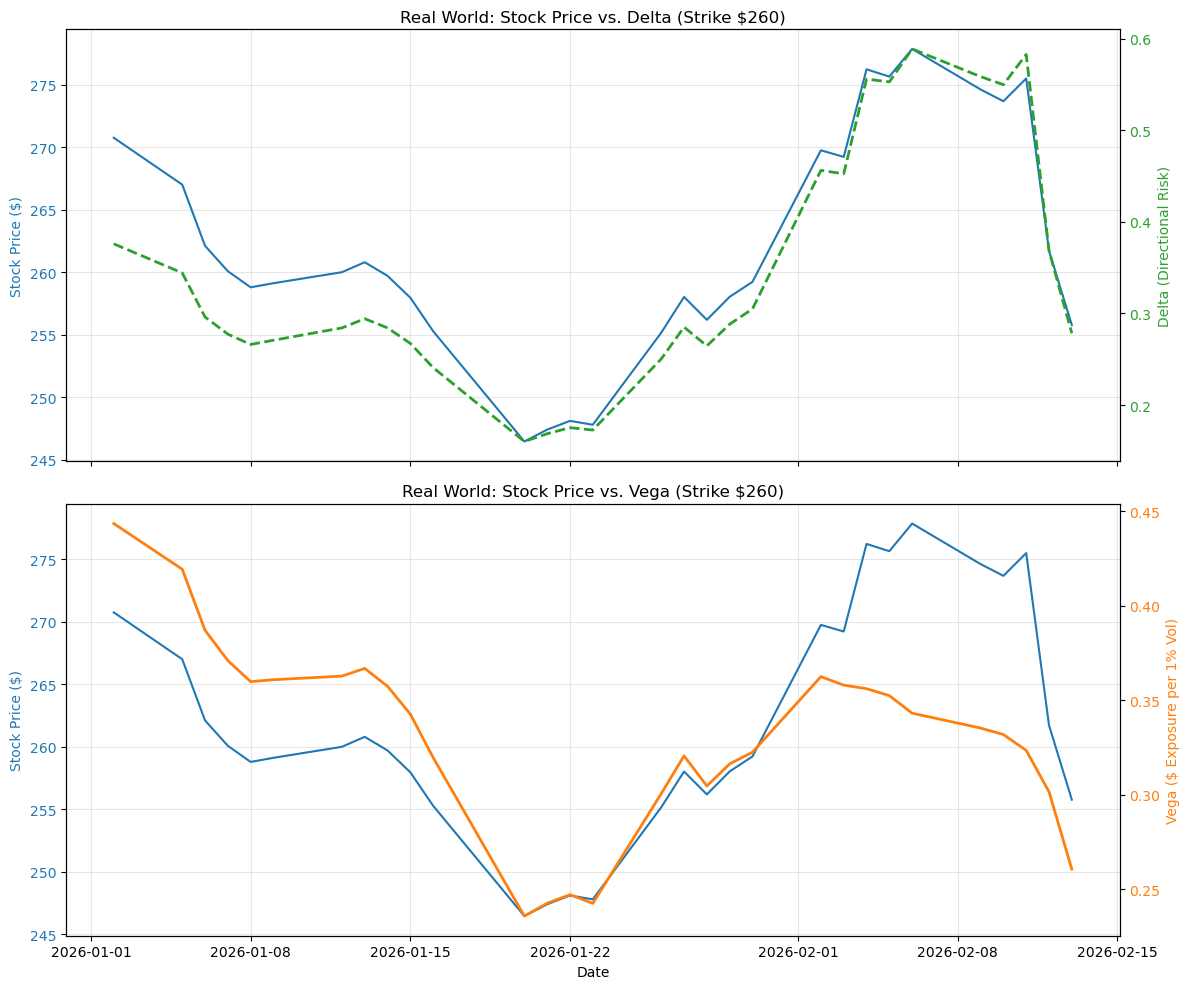

LATEST STATUS (2026-02-13):
Stock: $255.78
Delta: 0.28 (You are 'long' equivalent of 27 shares)
Vega:  $0.26 (You make $0.26 if IV goes up 1%)


In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Graph 1: Stock Price vs Delta
color = 'tab:blue'
ax1.set_ylabel('Stock Price ($)', color=color)
ax1.plot(df_hist.index, df_hist['StockPrice'], color=color, label='AAPL Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax1_right = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:green'
ax1_right.set_ylabel('Delta (Directional Risk)', color=color)
ax1_right.plot(df_hist.index, df_hist['Delta'], color=color, linestyle='--', linewidth=2, label='Option Delta')
ax1_right.tick_params(axis='y', labelcolor=color)
ax1.set_title(f"Real World: Stock Price vs. Delta (Strike ${target_strike})")

# Graph 2: Stock Price vs Vega
color = 'tab:blue'
ax2.set_xlabel('Date')
ax2.set_ylabel('Stock Price ($)', color=color)
ax2.plot(df_hist.index, df_hist['StockPrice'], color=color, label='AAPL Price')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(True, alpha=0.3)

ax2_right = ax2.twinx()
color = 'tab:orange'
ax2_right.set_ylabel('Vega ($ Exposure per 1% Vol)', color=color)
ax2_right.plot(df_hist.index, df_hist['Vega'], color=color, linestyle='-', linewidth=2, label='Option Vega')
ax2_right.tick_params(axis='y', labelcolor=color)
ax2.set_title(f"Real World: Stock Price vs. Vega (Strike ${target_strike})")

plt.tight_layout()
plt.show()

# Interpretation
last_row = df_hist.iloc[-1]
print(f"LATEST STATUS ({last_row.name.date()}):")
print(f"Stock: ${last_row['StockPrice']:.2f}")
print(f"Delta: {last_row['Delta']:.2f} (You are 'long' equivalent of {int(last_row['Delta']*100)} shares)")
print(f"Vega:  ${last_row['Vega']:.2f} (You make ${last_row['Vega']:.2f} if IV goes up 1%)")

# Alternative 2: Taylor Series Approximation (The "Tick-by-Tick" Method)

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [53]:
# Setup Parameters
S0 = 256.00    # Initial Stock Price
K = 256.00     # Strike Price
T = 14 / 365.0 # Time to Expiry (14 days)
r = 0.045       # Risk-Free Rate (4.5%)
sigma = 0.28   # Implied Volatility (28%)

In [37]:
# Defining the Black-Scholes & Greeks
def get_greeks(S, K, T, r, sigma):
    """
    Calculates exact Delta, Gamma, and Vega using Black-Scholes.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Delta
    delta = norm.cdf(d1)
    
    # Gamma
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    # Vega (Change in price per 1% Vol change)
    vega = S * np.sqrt(T) * norm.pdf(d1) / 100 
    
    return delta, gamma, vega

# Initial Snapshot (t0)
delta_0, gamma_0, vega_0 = get_greeks(S0, K, T, r, sigma)

# Calculate "Vanna" (Change in Vega w.r.t Stock Price) for approximation
# We use a tiny finite difference to get the slope of Vega at $256
eps = 0.01
_, _, vega_plus = get_greeks(S0 + eps, K, T, r, sigma)
_, _, vega_minus = get_greeks(S0 - eps, K, T, r, sigma)
vanna_0 = (vega_plus - vega_minus) / (2 * eps)

print(f"--- INITIAL SNAPSHOT ($256.00) ---")
print(f"Delta: {delta_0:.4f}")
print(f"Gamma: {gamma_0:.4f}")
print(f"Vega:  {vega_0:.4f}")
print(f"Vanna: {vanna_0:.6f} (Vega slope)")



--- INITIAL SNAPSHOT ($256.00) ---
Delta: 0.5228
Gamma: 0.0361
Vega:  0.1997
Vanna: -0.000255 (Vega slope)


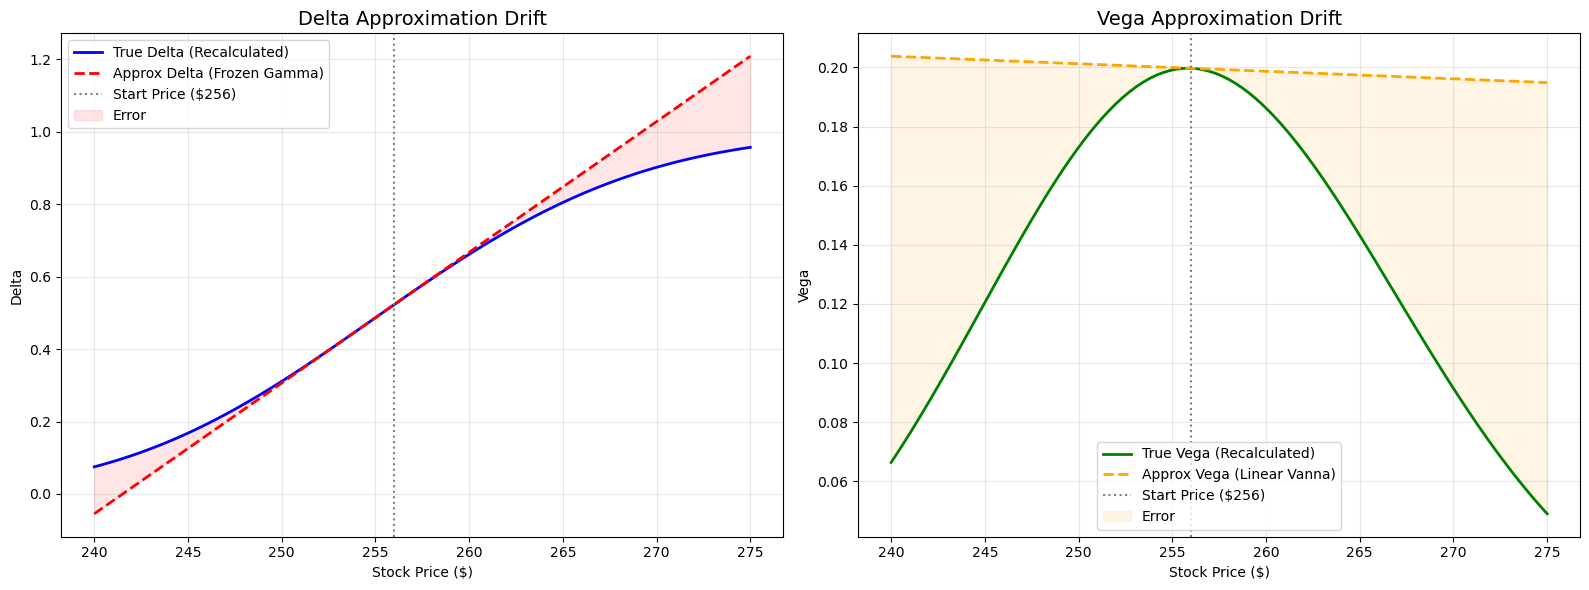

In [39]:
# Simulation Loop
prices = np.linspace(240, 275, 100) # Simulate stock moving from $240 to $275
true_deltas = []
approx_deltas = []
true_vegas = []
approx_vegas = []

for S_curr in prices:
    dS = S_curr - S0  # Change in Stock Price
    
    # --- A. TRUE VALUES (Recalculated) ---
    d_true, g_true, v_true = get_greeks(S_curr, K, T, r, sigma)
    true_deltas.append(d_true)
    true_vegas.append(v_true)
    
    # --- B. APPROXIMATED VALUES (Taylor Series) ---
    
    # Delta Approximation: New Delta = Old Delta + (Gamma * dS)
    d_approx = delta_0 + (gamma_0 * dS)
    approx_deltas.append(d_approx)
    
    # Vega Approximation: New Vega = Old Vega + (Vanna * dS)
    # (Note: Most simple models assume Vega is constant, but here we use Vanna for better accuracy)
    v_approx = vega_0 + (vanna_0 * dS)
    approx_vegas.append(v_approx)

# Plotting The Graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Delta Drift
ax1.plot(prices, true_deltas, 'b-', label='True Delta (Recalculated)', linewidth=2)
ax1.plot(prices, approx_deltas, 'r--', label='Approx Delta (Frozen Gamma)', linewidth=2)
ax1.set_title('Delta Approximation Drift', fontsize=14)
ax1.set_xlabel('Stock Price ($)')
ax1.set_ylabel('Delta')
ax1.axvline(S0, color='gray', linestyle=':', label='Start Price ($256)')
ax1.fill_between(prices, true_deltas, approx_deltas, color='red', alpha=0.1, label='Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Vega Drift
ax2.plot(prices, true_vegas, 'g-', label='True Vega (Recalculated)', linewidth=2)
ax2.plot(prices, approx_vegas, 'orange', linestyle='--', label='Approx Vega (Linear Vanna)', linewidth=2)
ax2.set_title('Vega Approximation Drift', fontsize=14)
ax2.set_xlabel('Stock Price ($)')
ax2.set_ylabel('Vega')
ax2.axvline(S0, color='gray', linestyle=':', label='Start Price ($256)')
ax2.fill_between(prices, true_vegas, approx_vegas, color='orange', alpha=0.1, label='Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()